<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/tarea_arboles_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Jorge Santiago Arroyo Chuquín  
**Fecha:** 25/06/2026

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [2]:
# TODO: Cargar el dataset car.data
#
# Instrucciones:
# 1. Defina los nombres de columnas en una lista:
#    col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# 2. Use pd.read_csv() para cargar 'car.data' con header=None y names=col_names
# 3. Imprima las dimensiones del dataset con df.shape
# 4. Muestre las primeras 5 filas con df.head()

# 1. Definción de COlumnas
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# lectura de car.csv
df= pd.read_csv('car.data', header=None, names=col_names)
#3. Muestra la cantidad de finlas y columnas del dataset cargado
print(df.shape)
#4. Muestra las primeras cinco filas
df.head()


(1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** _B)

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [3]:
# TODO: Explorar información del dataset
#
# Instrucciones:
# 1. Use df.info() para ver tipos de datos y valores no nulos
# 2. Use df.describe() para estadísticas descriptivas

#1. Muestra información general del data frame
df.info()
#2. Presenta estadísticas descriptivas
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [4]:
# TODO: Verificar valores únicos por columna
#
# Instrucciones:
# 1. Use un loop for para recorrer df.columns
# 2. Para cada columna, imprima df[col].unique()

#Recorre cada columna del Dataframe para conocer las categorias disponibles
for col in df.columns:
  print(col, df[col].unique())    #Imprime el nombre de la columna y sus valores unicos


buying ['vhigh' 'high' 'med' 'low']
maint ['vhigh' 'high' 'med' 'low']
doors ['2' '3' '4' '5more']
persons ['2' '4' 'more']
lug_boot ['small' 'med' 'big']
safety ['low' 'med' 'high']
class ['unacc' 'acc' 'vgood' 'good']


In [5]:
# TODO: Verificar valores nulos
#
# Instrucciones:
# 1. Use df.isnull().sum() para contar valores nulos por columna

print(df.isnull().sum())           #Cuenta los valores faltantes por columna


buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


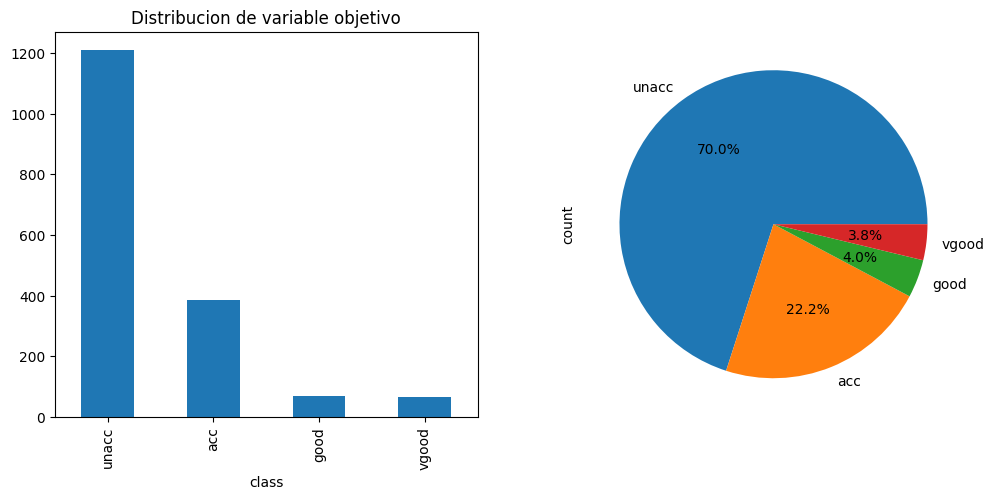

In [6]:
# TODO: Visualizar la distribución de la variable objetivo
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use df['class'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas apropiadas
# 5. Imprima el conteo de clases con df['class'].value_counts()

#1. Crea figura de 2 subplots para analizar la variable onjetivo
fig, axes=plt.subplots(1,2,figsize=(12,5))

#2. Grafca la frecuencia absoluta de cada clase
df['class'].value_counts().plot(kind='bar',ax=axes[0])
axes[0].set_title('Distribucion de variable objetivo')  # Asigna titulo a grafico de barras

#3. Grafica la disrtibución de clases en un grafico de pastel
df['class'].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=axes[1]) # Asigna titulo a grafico de pastel

#5. Muestra el conteo numérico de cada clase

print(df['class'].value_counts())





### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C)

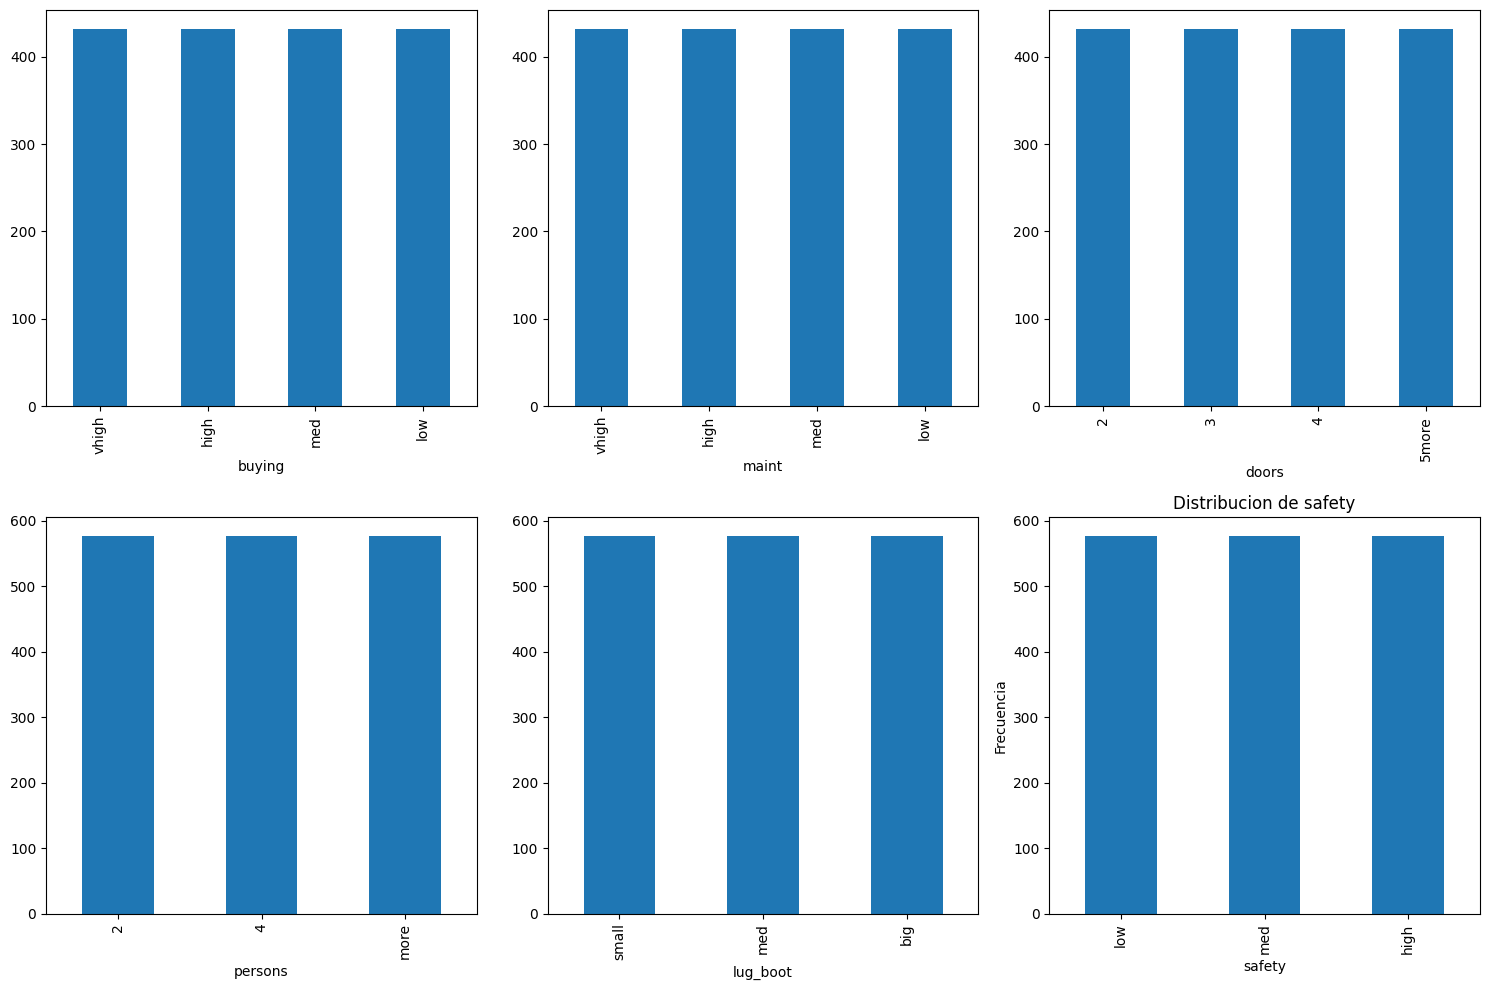

In [7]:
# TODO: Visualizar distribución de características
#
# Instrucciones:
# 1. Cree una figura con subplots 2x3 usando plt.subplots(2, 3, figsize=(15, 10))
# 2. Defina features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
# 3. Use un loop para graficar df[feature].value_counts().plot(kind='bar') en cada subplot
# 4. Agregue títulos a cada subplot

#1. Subplots 2x3
fig, axes=plt.subplots(2,3,figsize=(15,10))

#2. Variables categoricas  a graficar
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

#3. Loop para graficar df[feature]
for feature, ax in zip(features, axes.flatten()):
  conteo= df[feature].value_counts()
  conteo.plot(kind='bar',ax=ax)

#4. Agregar titulo a cada subplot

ax.set_title(f'Distribucion de {feature}')

#Nombre eje X
ax.set_xlabel(feature)

#Nombre eje y
ax.set_ylabel('Frecuencia')

plt.tight_layout()

plt.show()


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B)

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [8]:
# TODO: Aplicar Label Encoding a todas las columnas
#
# Instrucciones:
# 1. Cree una copia del DataFrame: df_encoded = df.copy()
# 2. Cree un diccionario vacío: label_encoders = {}
# 3. Para cada columna en df_encoded.columns:
#    a. Cree un LabelEncoder: le = LabelEncoder()
#    b. Transforme la columna: df_encoded[col] = le.fit_transform(df_encoded[col])
#    c. Guarde el encoder: label_encoders[col] = le
# 4. Muestre las primeras filas del DataFrame codificado

#1. Copia de data set original
df_encoded = df.copy()
#2. Creacion de diccionario vacio
label_encoders={}
#3. Recorrido de cada columna
for col in df_encoded.columns:
  le=LabelEncoder()                                   # Crea un codificador independiente para la columna actual
  df_encoded[col]=le.fit_transform(df_encoded[col])   #Ajusta el codificador y transforma texto en enteros
  label_encoders[col]=le                              # Guarda el codificador

#4. Muestra las primeras filas del data set
df_encoded.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [9]:
# TODO: Mostrar el mapeo de etiquetas
#
# Instrucciones:
# 1. Para cada columna y encoder en label_encoders.items():
#    - Imprima el mapeo usando dict(zip(le.classes_, range(len(le.classes_))))

for col, le in label_encoders.items():
  print(col,dict(zip(le.classes_,range(len(le.classes_)))))



buying {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
maint {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
doors {'2': 0, '3': 1, '4': 2, '5more': 3}
persons {'2': 0, '4': 1, 'more': 2}
lug_boot {'big': 0, 'med': 1, 'small': 2}
safety {'high': 0, 'low': 1, 'med': 2}
class {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B)

## Parte 4: División de Datos

In [10]:
# TODO: Separar características (X) y variable objetivo (y)
#
# Instrucciones:
# 1. X = df_encoded.drop('class', axis=1) para obtener solo las características
# 2. y = df_encoded['class'] para obtener la variable objetivo
# 3. Imprima las formas de X y y
# 4. Imprima los nombres de las características con list(X.columns)

#1 Separa las características predictoras eliminando la columna objetivo class
X=df_encoded.drop('class', axis=1)

#2.Definde la variable objetivo que contiene la evaluación del automovil
y=df_encoded['class']

#3. Imprime las formas X y Y
print('Forma de X: ', X.shape)
print('Forma de Y: ', y.shape)

#4. Imprime los nombres de las características usadas por el modelo
print('Características: ', list(X.columns))

Forma de X:  (1728, 6)
Forma de Y:  (1728,)
Características:  ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [11]:
# TODO: Dividir en conjuntos de entrenamiento y prueba
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.33, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.33, random_state=42)

print('Tamaño X_train: ', X_train.shape)
print('Tamaño X_test: ', X_test.shape)
print('Tamaño y_train: ', y_train.shape)
print('tamaño y_test: ', y_test.shape)


Tamaño X_train:  (1157, 6)
Tamaño X_test:  (571, 6)
Tamaño y_train:  (1157,)
tamaño y_test:  (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** C)

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [27]:
# TODO: Crear y entrenar el modelo con criterio Gini
#
# Instrucciones:
# 1. Cree el clasificador: clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# 2. Entrene con clf_gini.fit(X_train, y_train)
# 3. Imprima la profundidad del árbol con clf_gini.get_depth()
# 4. Imprima el número de hojas con clf_gini.get_n_leaves()

#1. Crea un arbol de decisión usando Gini como criterio de impureza
clf_gini=DecisionTreeClassifier(
    criterion='gini',     #Mide la impureza con Gini Index
    max_depth=3,          #Liomita la profundidad para limitar sobreajuste
    random_state=35
)

#2. Entrena el arbol con los datos de entrenamiento.
clf_gini.fit(X_train, y_train)

#3. Imprime la profundidad real alcanzada por el árbol entrenado
print('Profundidad: ', clf_gini.get_depth())

#4. Imprime el numero de hojas o nodos terminales de un arbol
print('Numero de hojas:', clf_gini.get_n_leaves())




Profundidad:  3
Numero de hojas: 5


In [28]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con y_pred_gini = clf_gini.predict(X_test)
# 2. Calcule la precisión en test con accuracy_score(y_test, y_pred_gini)
# 3. Prediga en train y calcule la precisión en entrenamiento
# 4. Imprima ambas precisiones

#Predice las clases del conjunto de prueba.
y_pred_gini=clf_gini.predict(X_test)

#Calcula la precisión del modelo en los datos de prueba
accuracy_gini_test=accuracy_score(y_test,y_pred_gini)

#Predice las clases del conjunto de entrenamiento
y_pred_gini_train=clf_gini.predict(X_train)

#Calcula la precisión del modelo en entrenamiento
accuracy_gini_train=accuracy_score(y_train, y_pred_gini_train)

print('Precisión train: ',accuracy_gini_train)
print('Precision test: ',accuracy_gini_test)


Precisión train:  0.7744165946413137
Precision test:  0.7653239929947461


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B)

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [30]:
# TODO: Crear y entrenar el modelo con criterio Entropy
#
# Instrucciones:
# 1. Cree el clasificador: clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# 2. Entrene con clf_entropy.fit(X_train, y_train)
# 3. Imprima la profundidad y número de hojas

#1. Crea un arbol de decisión usando Entropy como criterio de división
clf_entropy=DecisionTreeClassifier(
    criterion='entropy',       #mide la incertidumbre con entropía
    max_depth=3,
    random_state=42
)

#Entrena el modelo con el conjunto de entrenamiento
clf_entropy.fit(X_train, y_train)

#Imprime la profundidad real del árbol
print('Profundidad: ', clf_entropy.get_depth())

#Imprime la cantidad de hojas del árbol
print('Numero de hojas: ', clf_entropy.get_n_leaves())




Profundidad:  3
Numero de hojas:  5


In [31]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con clf_entropy.predict(X_test)
# 2. Calcule y muestre la precisión en test y train

#Predice las clases del conjunto de prueba.
y_pred_entropy=clf_entropy.predict(X_test)

#Calcula la precisión del modelo en los datos de prueba
accuracy_entropy_test=accuracy_score(y_test,y_pred_entropy)

#Predice las clases del conjunto de entrenamiento
y_pred_entropy_train=clf_entropy.predict(X_train)

#Calcula la precisión del modelo en entrenamiento
accuracy_entropy_train=accuracy_score(y_train, y_pred_entropy_train)

print('Precisión train: ',accuracy_entropy_train)
print('Precision test: ',accuracy_entropy_test)


Precisión train:  0.7744165946413137
Precision test:  0.7653239929947461


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C)

## Parte 7: Comparación de Modelos

In [32]:
# TODO: Crear tabla comparativa
#
# Instrucciones:
# 1. Cree un DataFrame con las siguientes columnas:
#    - 'Criterio': ['Gini Index', 'Entropy']
#    - 'Precisión Train': precisiones de entrenamiento
#    - 'Precisión Test': precisiones de prueba
#    - 'Profundidad': profundidad de cada árbol
#    - 'Hojas': número de hojas de cada árbol
# 2. Imprima la tabla

#Creación de data Frame
comparison_df =pd.DataFrame({
    'Criterio': ['Gini Index', 'Entropy'], #Nombnres de los criterios evaluados
    'Precision Train': [accuracy_gini_train, accuracy_entropy_train],  #Precisión obtenida en el entrenamiento de cada criterio
    'Precisión Test': [accuracy_gini_test, accuracy_entropy_test],     #Presición obtenida en la prueba para cada criterio
    'Profundidad': [clf_gini.get_depth(), clf_entropy.get_depth()],    #Pprofundidad real de cada arbol
    'Hojas': [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]

})

#Imprime la tabla comparativa
print(comparison_df)

     Criterio  Precision Train  Precisión Test  Profundidad  Hojas
0  Gini Index         0.774417        0.765324            3      5
1     Entropy         0.774417        0.765324            3      5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B)

## Parte 8: Matriz de Confusión y Métricas

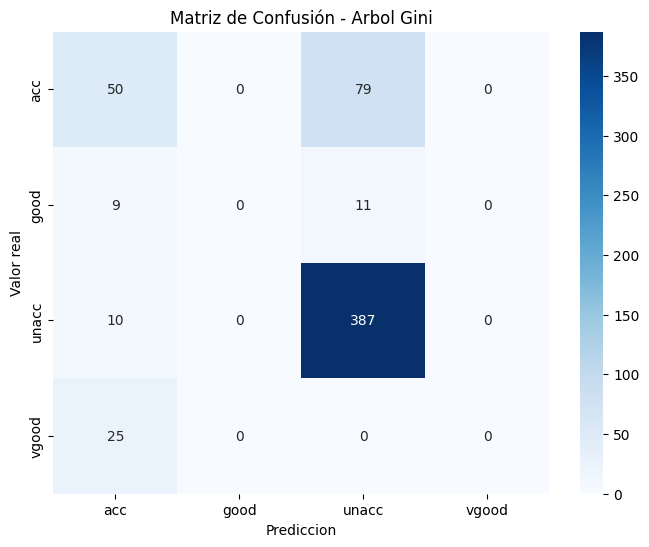

In [33]:
# TODO: Calcular y visualizar la matriz de confusión para el modelo Gini
#
# Instrucciones:
# 1. Calcule la matriz con confusion_matrix(y_test, y_pred_gini)
# 2. Obtenga los nombres de clase con label_encoders['class'].classes_
# 3. Use sns.heatmap() para visualizar con annot=True, fmt='d', cmap='Blues'
# 4. Configure xticklabels y yticklabels con los nombres de clase
# 5. Agregue título y etiquetas de ejes

#1. Calcula la matriz de confusión del modelo Gini
matriz_gini=confusion_matrix(y_test, y_pred_gini)

#2. Recupera los nombres originales de las clases desde el labelEncoder
class_names=label_encoders['class'].classes_

#3. Crea una figura para visulizar la matriz
plt.figure(figsize=(8,6))

#Dibuja un mapa de calor con los conteos de aciertos y errores
sns.heatmap(
    matriz_gini,annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,yticklabels=class_names
)
plt.title('Matriz de Confusión - Arbol Gini')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.show()

In [34]:
# TODO: Imprimir el reporte de clasificación
#
# Instrucciones:
# 1. Use classification_report(y_test, y_pred_gini, target_names=class_names)
# 2. Imprima el reporte

print(
    classification_report(y_test, y_pred_gini, target_names=class_names, zero_division=0)
)

              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C)

## Parte 9: Visualización del Árbol de Decisión

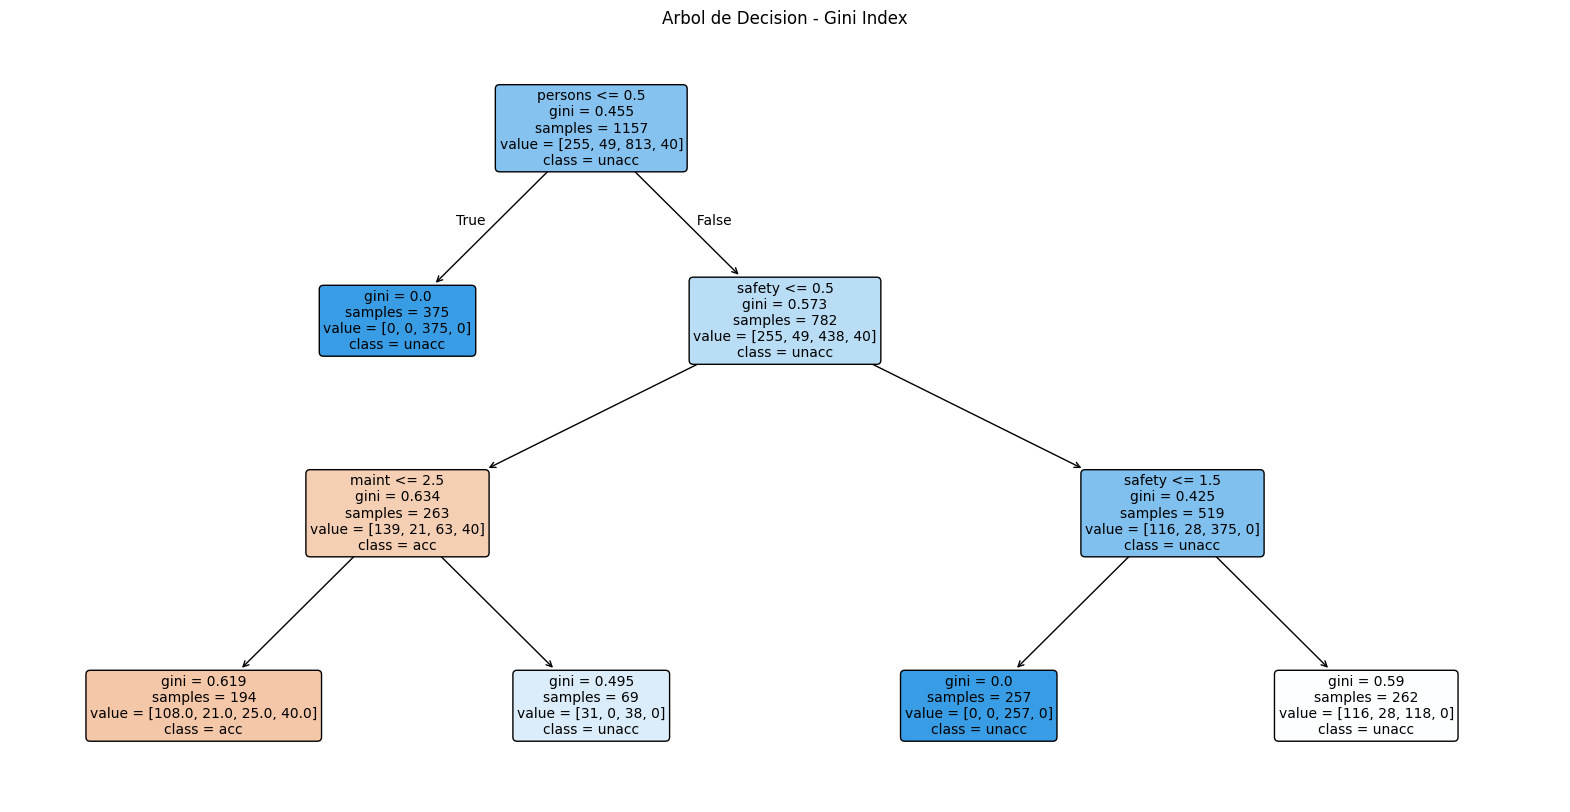

    Feature  Importance
5    safety    0.585506
3   persons    0.357400
1     maint    0.057095
0    buying    0.000000
2     doors    0.000000
4  lug_boot    0.000000


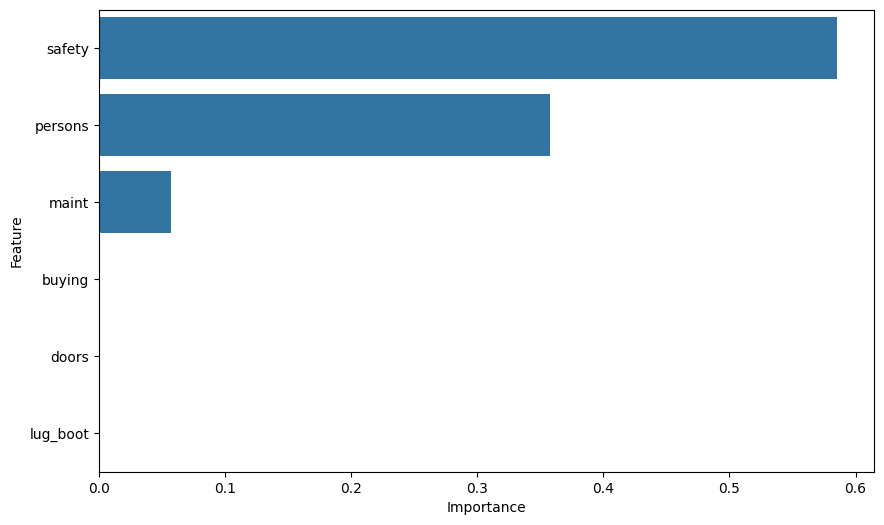

In [36]:
# TODO: Visualizar el árbol de decisión con Gini
#
# Instrucciones:
# 1. Cree una figura grande: plt.figure(figsize=(20, 10))
# 2. Use plot_tree() con los siguientes parámetros:
#    - clf_gini (el modelo)
#    - feature_names=list(X.columns)
#    - class_names=list(class_names)
#    - filled=True
#    - rounded=True
#    - fontsize=10
# 3. Agregue título

#Crear figura
plt.figure(figsize=(20,10))
#Dibujar el arbol entrenado con Gini
plot_tree(
    clf_gini,                           #modelo entrenado
    feature_names=list(X.columns),      #Nombres de las variables predictorias
    class_names=list(class_names),
    filled=True,
    rounded=True,
    fontsize=10
)

#Agrega título al gráfico
plt.title('Arbol de Decision - Gini Index')
#Muestra el arbol
plt.show()

#Crea un DataFrame con la importancia de cada característica
importances_df=pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
}).sort_values('Importance', ascending=False)

#Grafica la importancia de variables usando barras horizontales
sns.barplot(data=importances_df, x='Importance', y='Feature')

#Muestra la tabla de importacias.
print(importances_df)



In [20]:
# TODO: Mostrar la importancia de las características
#
# Instrucciones:
# 1. Cree un DataFrame con columnas 'Feature' y 'Importance'
#    - 'Feature': X.columns
#    - 'Importance': clf_gini.feature_importances_
# 2. Ordene por importancia descendente con sort_values()
# 3. Visualice con sns.barplot()
# 4. Imprima la tabla de importancias



### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C)

## Parte 10: Experimentación con Hiperparámetros

In [37]:
# TODO: Experimentar con diferentes valores de max_depth
#
# Instrucciones:
# 1. Defina depths = [1, 2, 3, 5, 7, 10, None] (None = sin límite)
# 2. Cree una lista vacía para resultados
# 3. Para cada depth:
#    a. Cree y entrene un DecisionTreeClassifier con ese max_depth
#    b. Calcule precisión en train y test
#    c. Guarde los resultados en un diccionario
# 4. Convierta a DataFrame e imprima

#1. Define diferentes profundidades maximas para evaluar complejidad del arbol

depths = [1,2,3,5,7,10, None]
resultados=[]  #lista vacia para almacenar resultados

#Recorre cada profundidad definida
for depth in depths:
  clf =DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=35)     #Entrena un arbol con la profundidad actual
  clf.fit(X_train, y_train)                                                           #Ajusta el modelo con los datos de entrenamiento
  train_acc=accuracy_score(y_train,clf.predict(X_train))                              #Calcula accuracy en entrenamiento y prueba
  test_acc=accuracy_score(y_test, clf.predict(X_test))
  #Guarda metricas y estructura del arbol
  resultados.append({
      'max_depth': depth,
      'Train Accuracy': test_acc,
      'Test Accuracy': test_acc,
      'Profundidad real': clf.get_depth(),
      'Hojas':clf.get_n_leaves()
  })
#Convierte la lista de resultados a DataFrame
depth_df =pd.DataFrame(resultados)
#imprime la tabla
print(depth_df)

   max_depth  Train Accuracy  Test Accuracy  Profundidad real  Hojas
0        1.0        0.695271       0.695271                 1      2
1        2.0        0.770578       0.770578                 2      3
2        3.0        0.765324       0.765324                 3      5
3        5.0        0.865149       0.865149                 5     13
4        7.0        0.935201       0.935201                 7     28
5       10.0        0.961471       0.961471                10     62
6        NaN        0.966725       0.966725                14     73


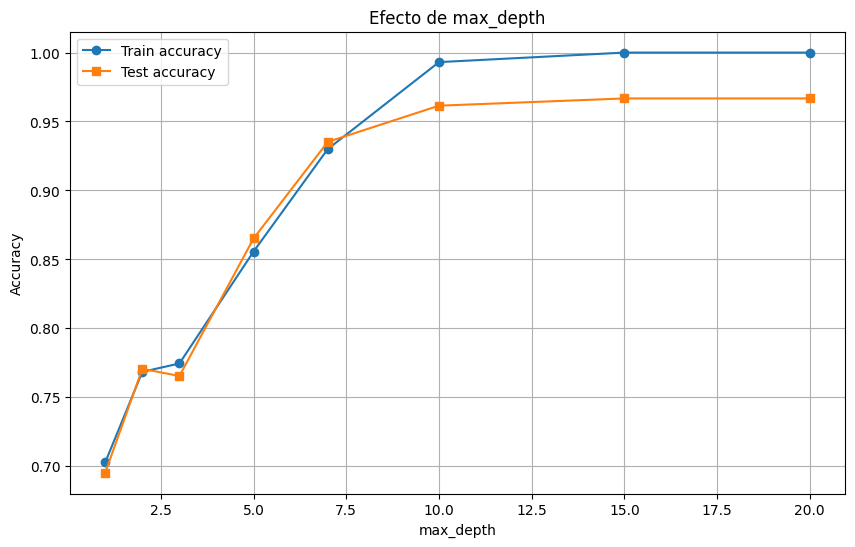

In [38]:
# TODO: Visualizar el efecto de max_depth
#
# Instrucciones:
# 1. Defina depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
# 2. Cree listas para train_scores y test_scores
# 3. Para cada depth, entrene un modelo y guarde las precisiones
# 4. Grafique ambas curvas (train y test) vs max_depth
# 5. Agregue leyenda, título y etiquetas

# Define las profundidades que se representarán en el gráfico.
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]

# Crea listas vacías para guardar accuracies de entrenamiento y prueba.
train_scores = []
test_scores = []

# Entrena un árbol para cada profundidad
for depth in depths_plot:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Grafica la curva de entrenamiento.
plt.plot(depths_plot, train_scores, marker='o', label='Train accuracy')
# Grafica la curva de prueba.
plt.plot(depths_plot, test_scores, marker='s', label='Test accuracy')
# Agrega título, etiquetas, leyenda y cuadrícula.
plt.title('Efecto de max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C)

In [39]:
# TODO: Experimentar con min_samples_split
#
# Instrucciones:
# 1. Defina min_samples_list = [2, 5, 10, 20, 50]
# 2. Para cada valor, entrene un modelo SIN limitar max_depth
# 3. Guarde precisión train, test, profundidad y hojas
# 4. Imprima los resultados en una tabla

#Define valoers de min samples split
min_samples_list=[2,5,10,20,50]
resultados_min=[]

#Evalua cada valor de min_samples_split
for m in min_samples_list:
  clf=DecisionTreeClassifier(criterion='gini', min_samples_split=m, random_state=35)
  clf.fit(X_train,y_train)
  resultados_min.append({
      'min_samples_split': m,
      'Train Accuracy': accuracy_score(y_train, clf.predict(X_train)),
      'Test Accuracy': accuracy_score(y_test, clf.predict(X_test)),
      'Profundidad': clf.get_depth(),
      'Hojas': clf.get_n_leaves()
  })

  # Convierte e imprime los resultados en forma de tabla.
min_df = pd.DataFrame(resultados_min)
print(min_df)

   min_samples_split  Train Accuracy  Test Accuracy  Profundidad  Hojas
0                  2        1.000000       0.966725           14     73
1                  5        0.991357       0.956217           12     62
2                 10        0.976664       0.942207           11     49
3                 20        0.953328       0.931699           10     38
4                 50        0.891098       0.886165            8     19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B)

## Parte 11: Modelo Final Optimizado

In [42]:
# TODO: Entrenar modelo final con los mejores hiperparámetros
#
# Instrucciones:
# 1. Basado en sus experimentos, elija los mejores hiperparámetros
#    (sugerencia: criterion='gini', max_depth=7, min_samples_split=5)
# 2. Cree y entrene el modelo final
# 3. Calcule y muestre la precisión en test y train
# 4. Muestre profundidad y número de hojas

# Crea el modelo final con hiperparámetros seleccionados tras la experimentación.

clf_final = DecisionTreeClassifier(
    criterion='gini',        # Usa Gini por su buen desempeño y simplicidad.
    max_depth=7,             # Limita la profundidad para controlar complejidad.
    min_samples_split=5,     # Evita divisiones con muy pocas muestras.
    random_state=42          # Garantiza reproducibilidad.
)
# Entrena el modelo final con los datos de entrenamiento.
clf_final.fit(X_train, y_train)
# Predice las etiquetas del conjunto de prueba.
y_pred_final = clf_final.predict(X_test)
# Calcula la precisión final en entrenamiento.
final_train_acc = accuracy_score(y_train, clf_final.predict(X_train))
# Calcula la precisión final en prueba.
final_test_acc = accuracy_score(y_test, y_pred_final)
# Imprime métricas de rendimiento y estructura del árbol.
print('Precisión train:', final_train_acc)
print('Precisión test:', final_test_acc)
print('Profundidad:', clf_final.get_depth())
print('Hojas:', clf_final.get_n_leaves())


Precisión train: 0.9282627484874676
Precisión test: 0.9334500875656743
Profundidad: 7
Hojas: 27


In [43]:
# TODO: Imprimir reporte de clasificación final
#
# Instrucciones:
# 1. Use classification_report() con las predicciones del modelo final

# Imprime el reporte de clasificación final.
print(classification_report(y_test, y_pred_final, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C)

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B)

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C)